# What the LDM-RL measurements actually support

**2026-09-04.** GRPO fine-tuning of a Qwen3.5-9B hybrid (Gated DeltaNet linear attention,
full attention at layers 3, 7, …, 31) for molecular acquisition-function optimisation, with a
Qwen2.5-1.5B control that trains cleanly. Five adversarial reviews of the campaign's own
records ran against this notebook's inputs; **four of the five load-bearing conclusions did not
survive**, and the one new positive result below was already in the logs, uncounted.

Every figure reads `results/session_20260904.json`, extracted once from the run logs, so a
figure and the sentence beside it cannot disagree.

In [1]:
import json, math, warnings
from pathlib import Path
import numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
warnings.filterwarnings("ignore")

# 300 dpi is a repo rule; at 300 dpi a PNG is ~9x the bytes of 100 dpi, which
# collides with the "committed notebook must still render inline" rule. Quantising
# to a 256-colour palette closes the gap. This must live in the NOTEBOOK, not only
# in the build script -- `nbconvert --execute` re-runs these cells and would
# otherwise emit unquantised images.
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
    "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.4,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
INK, HL, MUTE, WARN = "#22313f", "#c0392b", "#95a5a6", "#e67e22"
OK, ALT = "#27ae60", "#2980b9"

import io, base64
from IPython.display import display, Image as IPImage
try:
    from PIL import Image as PILImage
    def show(fig):
        buf = io.BytesIO(); fig.savefig(buf, format="png"); plt.close(fig); buf.seek(0)
        im = PILImage.open(buf).convert("RGB").quantize(colors=256, method=PILImage.MEDIANCUT)
        out = io.BytesIO(); im.save(out, format="PNG", optimize=True)
        display(IPImage(data=out.getvalue()))
except ImportError:
    def show(fig):
        display(fig); plt.close(fig)

D = json.loads(Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results/session_20260904.json").read_text())
print("extracted", D["generated_utc"], "|", D["n_run_dirs"], "run directories")

extracted 2026-09-04T14:39:23Z | 239 run directories


## 1. The reward cannot measure policy quality

The campaign's headline negative result was *"`raw_reward` fell from 0.0172 to 0.0023 across a
completed run, so the policy got worse."* The reward is expected hypervolume improvement
against an **evolving** Pareto front scored by a **growing** GP. It is a shrinking ruler.

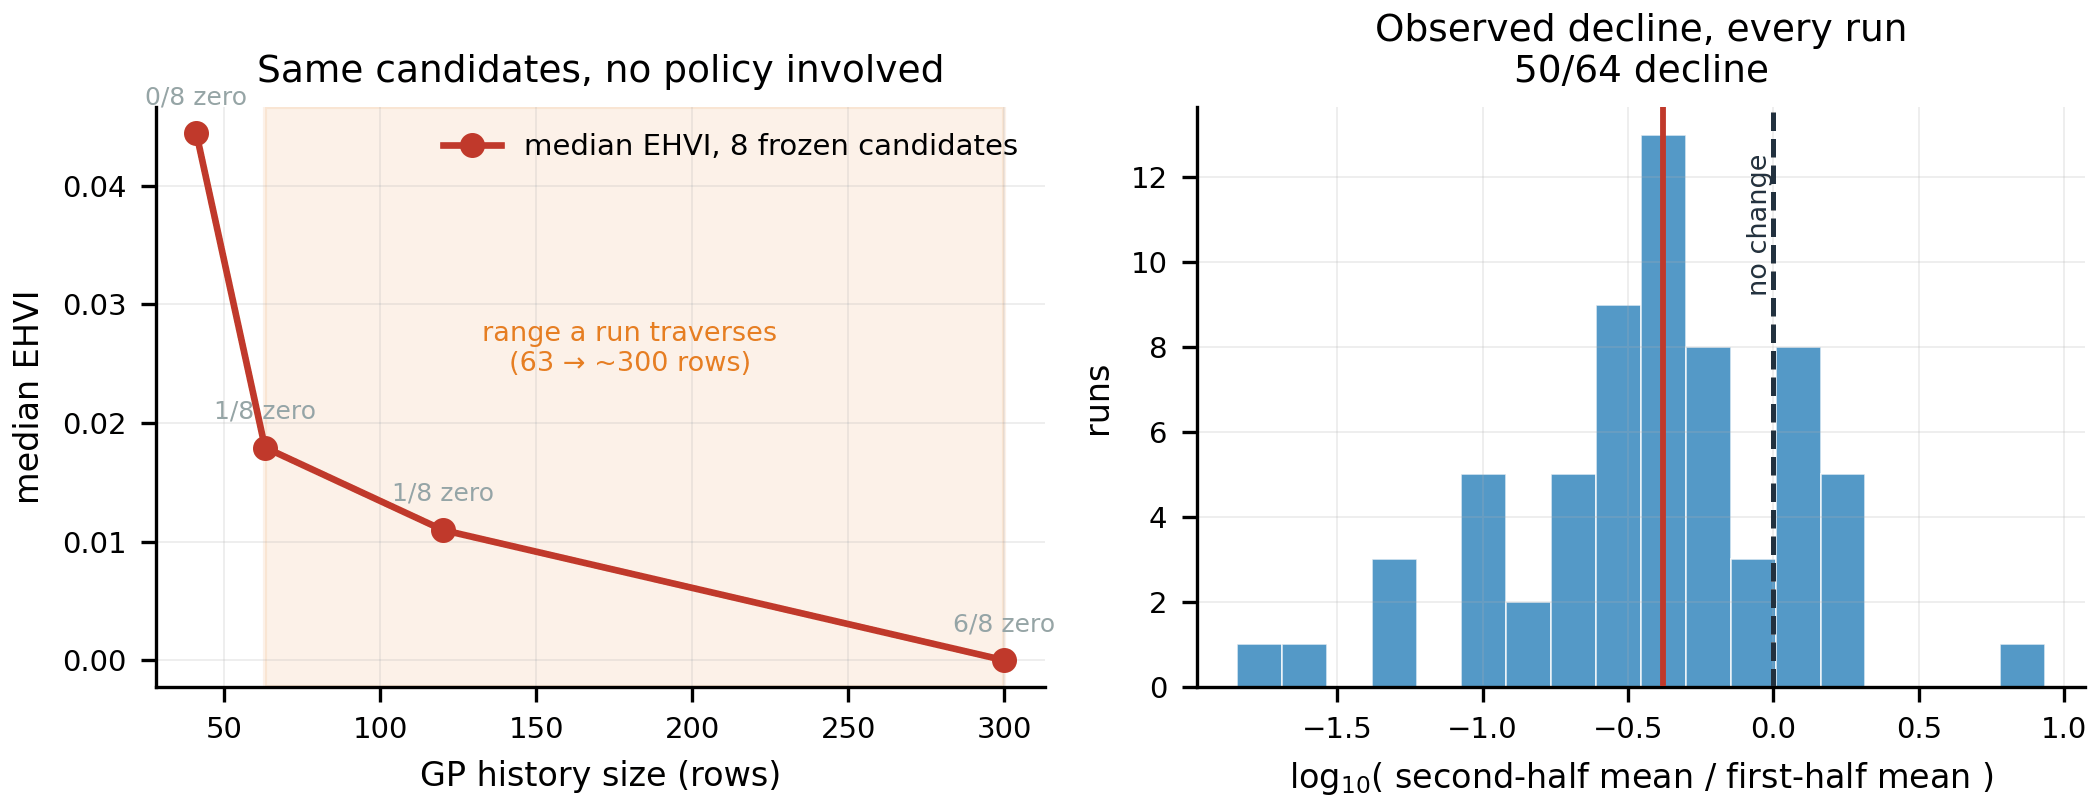

frozen candidates: median EHVI 0.04441 (n=41) -> 0.00000 (n=300)
runs with >=10 rounds: 50/64 decline, median ratio 0.416


In [2]:
eh = D["ehvi_vs_history"]["points"]
hn = [p["n_history"] for p in eh]; med = [p["median"] for p in eh]
zer = [p["n_zero"] for p in eh]

hv = D["halves"]
ratios = [h["ratio"] for h in hv if h["ratio"] and h["ratio"] > 0]
lr = np.log10(ratios)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.0, 2.7))

a1.plot(hn, med, "o-", color=HL, lw=1.6, ms=5, label="median EHVI, 8 frozen candidates")
a1.set_xlabel("GP history size (rows)"); a1.set_ylabel("median EHVI")
a1.set_title("Same candidates, no policy involved")
for x, y, z in zip(hn, med, zer):
    a1.annotate(f"{z}/8 zero", (x, y), textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=6, color=MUTE)
a1.axvspan(63, 300, color=WARN, alpha=0.10)
a1.annotate("range a run traverses\n(63 → ~300 rows)", (180, max(med)*0.55),
            ha="center", fontsize=6.5, color=WARN)
a1.legend(loc="upper right", frameon=False)

a2.hist(lr, bins=18, color=ALT, alpha=0.8, edgecolor="white", lw=0.4)
a2.axvline(0, color=INK, lw=1.2, ls="--")
a2.annotate("no change", (0, a2.get_ylim()[1]*0.92), rotation=90, fontsize=6.5,
            color=INK, ha="right", va="top")
a2.axvline(np.median(lr), color=HL, lw=1.4)
a2.set_xlabel("log$_{10}$( second-half mean / first-half mean )")
a2.set_ylabel("runs")
a2.set_title(f"Observed decline, every run\n{D['n_declining']}/{D['n_halves']} decline")
show(fig)

print(f"frozen candidates: median EHVI {med[0]:.5f} (n={hn[0]}) -> {med[-1]:.5f} (n={hn[-1]})")
print(f"runs with >=10 rounds: {D['n_declining']}/{D['n_halves']} decline, "
      f"median ratio {10**np.median(lr):.3f}")

**The decline is reproduced with the policy frozen.** Over exactly the history range a run
traverses, the same eight held-out candidates lose their entire EHVI (6 of 8 reach exactly zero),
and the decline appears in essentially every run regardless of reward form, group size or model
size. A quantity that falls in every configuration ever run is a property of the metric.
The sign is not even determined: a *better* policy fills the Pareto front faster and so drives
its own reward down faster.

**Retracted.** `raw_reward` carries no information about policy quality. Policy quality needs a
stationary yardstick — a fixed candidate set scored under a frozen GP.

## 2. The zero-variance rate is a function of where you stop looking

Zero-variance rollouts (all trajectories in a group score identically) produce no gradient, so
their rate is the campaign's main outcome measure. Runs die at different lengths, and the rate
drifts within a run — so a cell's number depends on how long its runs happened to survive.

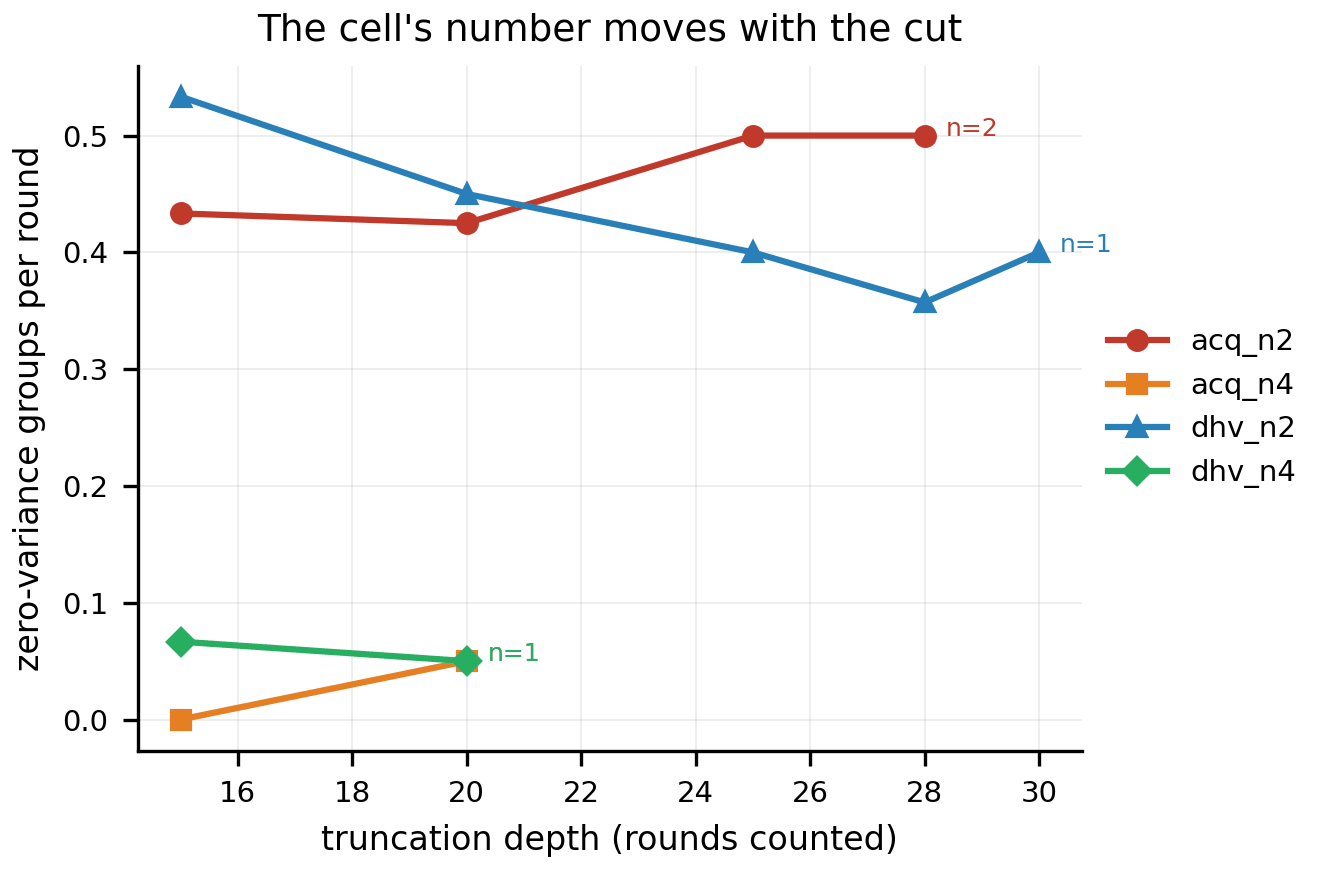

cut= 15  acq_n2=0.433 acq_n4=0.000 dhv_n2=0.533 dhv_n4=0.067
cut= 20  acq_n2=0.425 acq_n4=0.050 dhv_n2=0.450 dhv_n4=0.050
cut= 25  acq_n2=0.500 acq_n4=-- dhv_n2=0.400 dhv_n4=--
cut= 28  acq_n2=0.500 acq_n4=-- dhv_n2=0.357 dhv_n4=--
cut= 30  acq_n2=-- acq_n4=-- dhv_n2=0.400 dhv_n4=--


In [3]:
mx = D["matrix"]; curve = mx.get("cut_curve", {})
cuts = sorted(int(c) for c in curve)
CELLS = ["acq_n2", "acq_n4", "dhv_n2", "dhv_n4"]
COL = {"acq_n2": HL, "acq_n4": WARN, "dhv_n2": ALT, "dhv_n4": OK}
MK  = {"acq_n2": "o", "acq_n4": "s", "dhv_n2": "^", "dhv_n4": "D"}

fig, ax = plt.subplots(figsize=(4.4, 2.9))
for k in CELLS:
    xs, ys, ns = [], [], []
    for c in cuts:
        cc = curve[str(c)].get(k, {})
        if cc.get("runs"):
            xs.append(c); ys.append(cc["zs_rate"]); ns.append(cc["runs"])
    if xs:
        ax.plot(xs, ys, MK[k] + "-", color=COL[k], lw=1.5, ms=4.5, label=k)
        ax.annotate(f"n={ns[-1]}", (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(5, 0), fontsize=6, color=COL[k])
ax.set_xlabel("truncation depth (rounds counted)")
ax.set_ylabel("zero-variance groups per round")
ax.set_title("The cell's number moves with the cut")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
show(fig)

for c in cuts:
    row = " ".join(f"{k}={curve[str(c)][k]['zs_rate']:.3f}" if curve[str(c)][k].get("runs")
                   else f"{k}=--" for k in CELLS)
    print(f"cut={c:>3}  {row}")

**At a common cut the two `n=4` cells are indistinguishable**, while the published table reported
the acquisition/ΔHV ratio there as 5.19×. That ratio compared cells measured at 60, 22, 52 and
133 rounds. The `n=2` versus `n=4` gap, by contrast, is present at every depth.

## 3. The group-size cell was also getting twice the training

`launchers/run_train_real_slime_param.sh` hard-coded `--global-batch-size 2` while
`--n-samples-per-prompt` was the knob under study. Optimiser steps per round =
`rollout_batch × n_samples ÷ global_batch`, so the knob moved the training budget too.

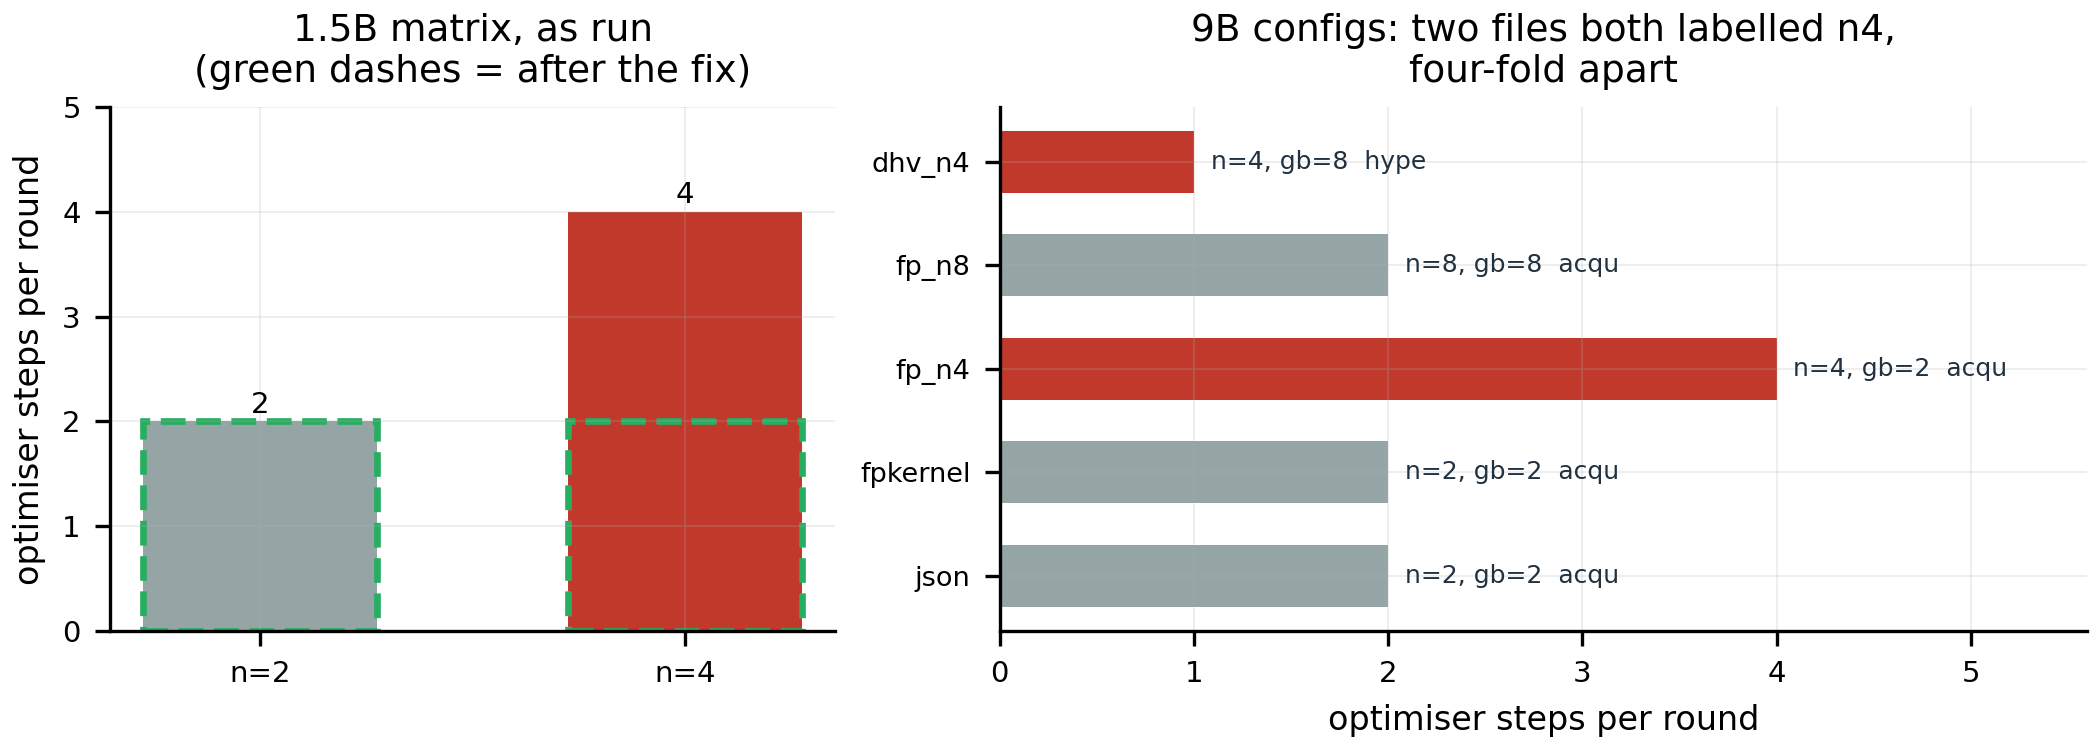

json             rb=2 n=2 gb=2 -> 2.0 updates/round  (acquisition)
fpkernel.json    rb=2 n=2 gb=2 -> 2.0 updates/round  (acquisition)
fp_n4.json       rb=2 n=4 gb=2 -> 4.0 updates/round  (acquisition)
fp_n8.json       rb=2 n=8 gb=8 -> 2.0 updates/round  (acquisition)
dhv_n4.json      rb=2 n=4 gb=8 -> 1.0 updates/round  (hypervolume)


In [4]:
mc = D["matrix_confound"]; cf = D["config_confound"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.0, 2.5),
                             gridspec_kw={"width_ratios": [1, 1.5]})

lbl = [m["cell"] for m in mc]; upr = [m["updates_per_rollout"] for m in mc]
b = a1.bar(lbl, upr, color=[MUTE, HL], width=0.55)
a1.bar(lbl, [2, 2], color="none", edgecolor=OK, lw=1.6, ls="--", width=0.55)
for r, v in zip(b, upr):
    a1.annotate(f"{v:.0f}", (r.get_x()+r.get_width()/2, v), textcoords="offset points",
                xytext=(0, 2), ha="center", fontsize=7)
a1.set_ylabel("optimiser steps per round")
a1.set_title("1.5B matrix, as run\n(green dashes = after the fix)")
a1.set_ylim(0, 5)

names = [c["config"].replace(".json", "").replace("config_real.isambard.", "") for c in cf]
vals  = [c["updates_per_rollout"] for c in cf]
cols  = [HL if c["n_samples"] == 4 else MUTE for c in cf]
a2.barh(range(len(names)), vals, color=cols, height=0.6)
a2.set_yticks(range(len(names))); a2.set_yticklabels(names, fontsize=6.5)
a2.set_xlabel("optimiser steps per round")
a2.set_title("9B configs: two files both labelled n4,\nfour-fold apart")
for i, c in enumerate(cf):
    a2.annotate(f"n={c['n_samples']}, gb={c['global_batch']}  {c['reward'][:4]}",
                (vals[i], i), textcoords="offset points", xytext=(4, 0),
                va="center", fontsize=6, color=INK)
a2.set_xlim(0, 5.6)
show(fig)

for c in cf:
    print(f"{c['config']:16} rb={c['rollout_batch']} n={c['n_samples']} "
          f"gb={c['global_batch']} -> {c['updates_per_rollout']:.1f} updates/round  ({c['reward']})")

**The `n=4` cells received exactly twice the gradient updates of the `n=2` cells** at the same
round count, so "group size is an effective knob" was never separated from "twice the training".
On the 9B side the two configuration files both labelled `n4` differ four-fold on the same axis.

Fixed: the launcher now declares `UPDATES_PER_ROLLOUT`, derives `global_batch` from it, asserts
divisibility, and prints the resolved triple — the pattern this repo's own conventions already
mandate elsewhere and which this line had never applied.

## 4. The 9B and 1.5B gradient distributions do not overlap

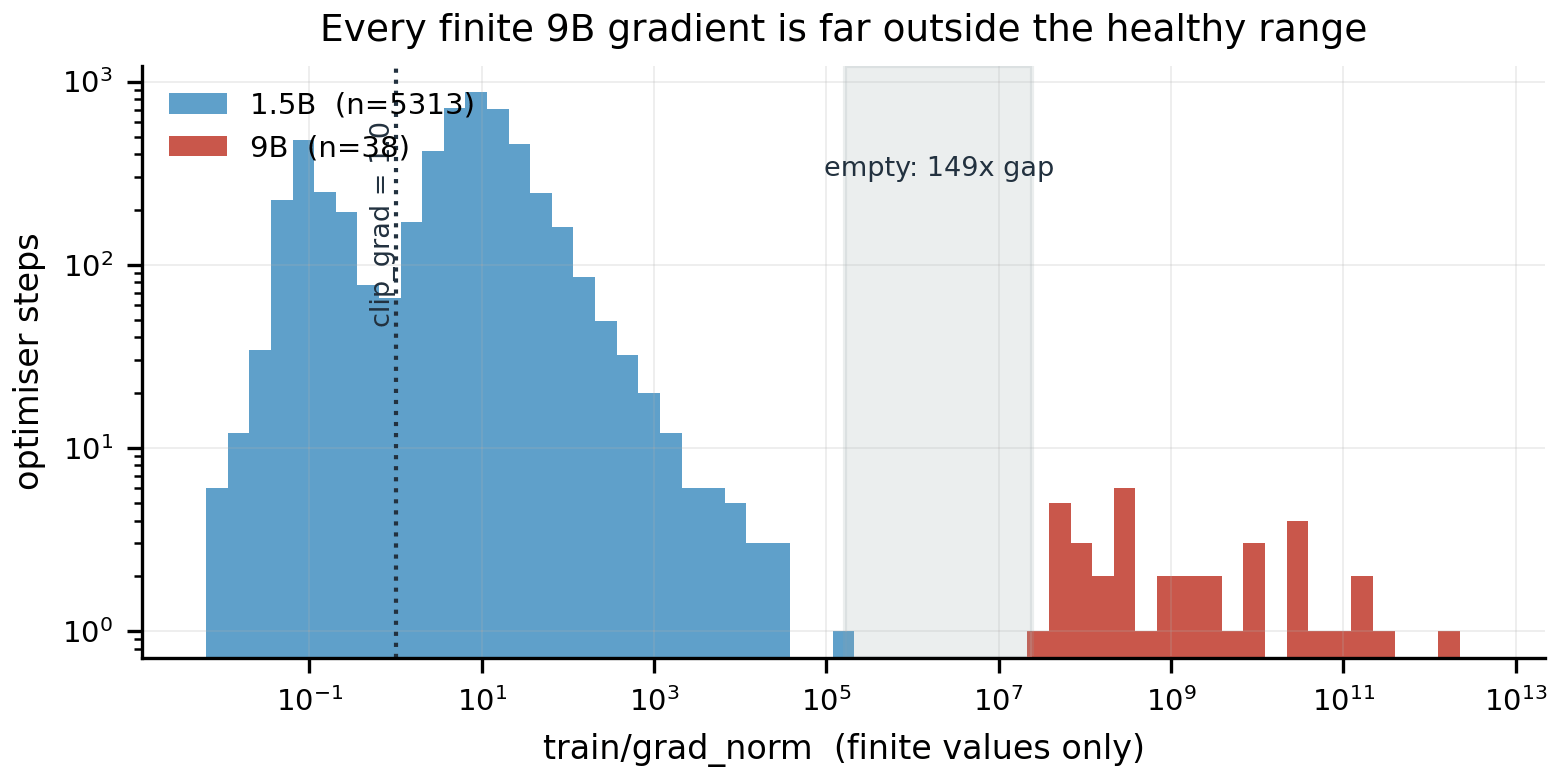

1.5B  min 0.0099  median 6.488  max 1.655e+05
9B    min 2.467e+07  median 7.857e+08  max 2.064e+12
separation: 9B minimum is 149x the 1.5B maximum


In [5]:
g9 = np.array(D["grad_norms"]["9B"]["values"], float)
g1 = np.array(D["grad_norms"]["1.5B"]["values"], float)
g9 = g9[g9 > 0]; g1 = g1[g1 > 0]

fig, ax = plt.subplots(figsize=(5.2, 2.6))
bins = np.logspace(-2.2, 12.6, 60)
ax.hist(g1, bins=bins, color=ALT, alpha=0.75, label=f"1.5B  (n={len(g1)})", edgecolor="none")
ax.hist(g9, bins=bins, color=HL, alpha=0.85, label=f"9B  (n={len(g9)})", edgecolor="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("train/grad_norm  (finite values only)"); ax.set_ylabel("optimiser steps")
ax.axvspan(g1.max(), g9.min(), color=MUTE, alpha=0.18)
ax.annotate(f"empty: {g9.min()/g1.max():.0f}x gap",
            (math.sqrt(g1.max()*g9.min()), ax.get_ylim()[1]*0.25),
            ha="center", fontsize=6.5, color=INK)
ax.axvline(1.0, color=INK, lw=1.0, ls=":")
ax.annotate("clip_grad = 1.0", (1.0, ax.get_ylim()[1]*0.5), rotation=90,
            fontsize=6.5, ha="right", va="top", color=INK)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Every finite 9B gradient is far outside the healthy range")
show(fig)

print(f"1.5B  min {g1.min():.4g}  median {np.median(g1):.4g}  max {g1.max():.4g}")
print(f"9B    min {g9.min():.4g}  median {np.median(g9):.4g}  max {g9.max():.4g}")
print(f"separation: 9B minimum is {g9.min()/g1.max():.0f}x the 1.5B maximum")

**No 9B step has ever produced a gradient within five orders of magnitude of the healthy scale.**
The distributions are disjoint: the smallest 9B gradient exceeds the largest 1.5B gradient by
two orders. Since `clip_grad = 1.0` rescales by a positive scalar, the *direction* is preserved
exactly — so "the direction is noise" was never shown. What the data does support is
**concentration**: with one tensor at ~1e8 and the output layer at ~2e-2, after clipping to unit
norm most parameters receive an update of order 1e-9 of nominal, making the update effectively
rank-few.

## 5. The nan boundary lands on a full-attention layer, 64 times out of 64

The backward pass runs layer 31 → 0, so the **largest** contaminated layer index is where the
non-finite value first appears. The published table gave one such index per run and built a
between-run contrast on it. Each run in fact emits ten reports per rank, and the index varies
*within* every run — so the contrast was an artefact of which line was tabulated. Counting all
of them gives a much stronger result than the one that was reported.

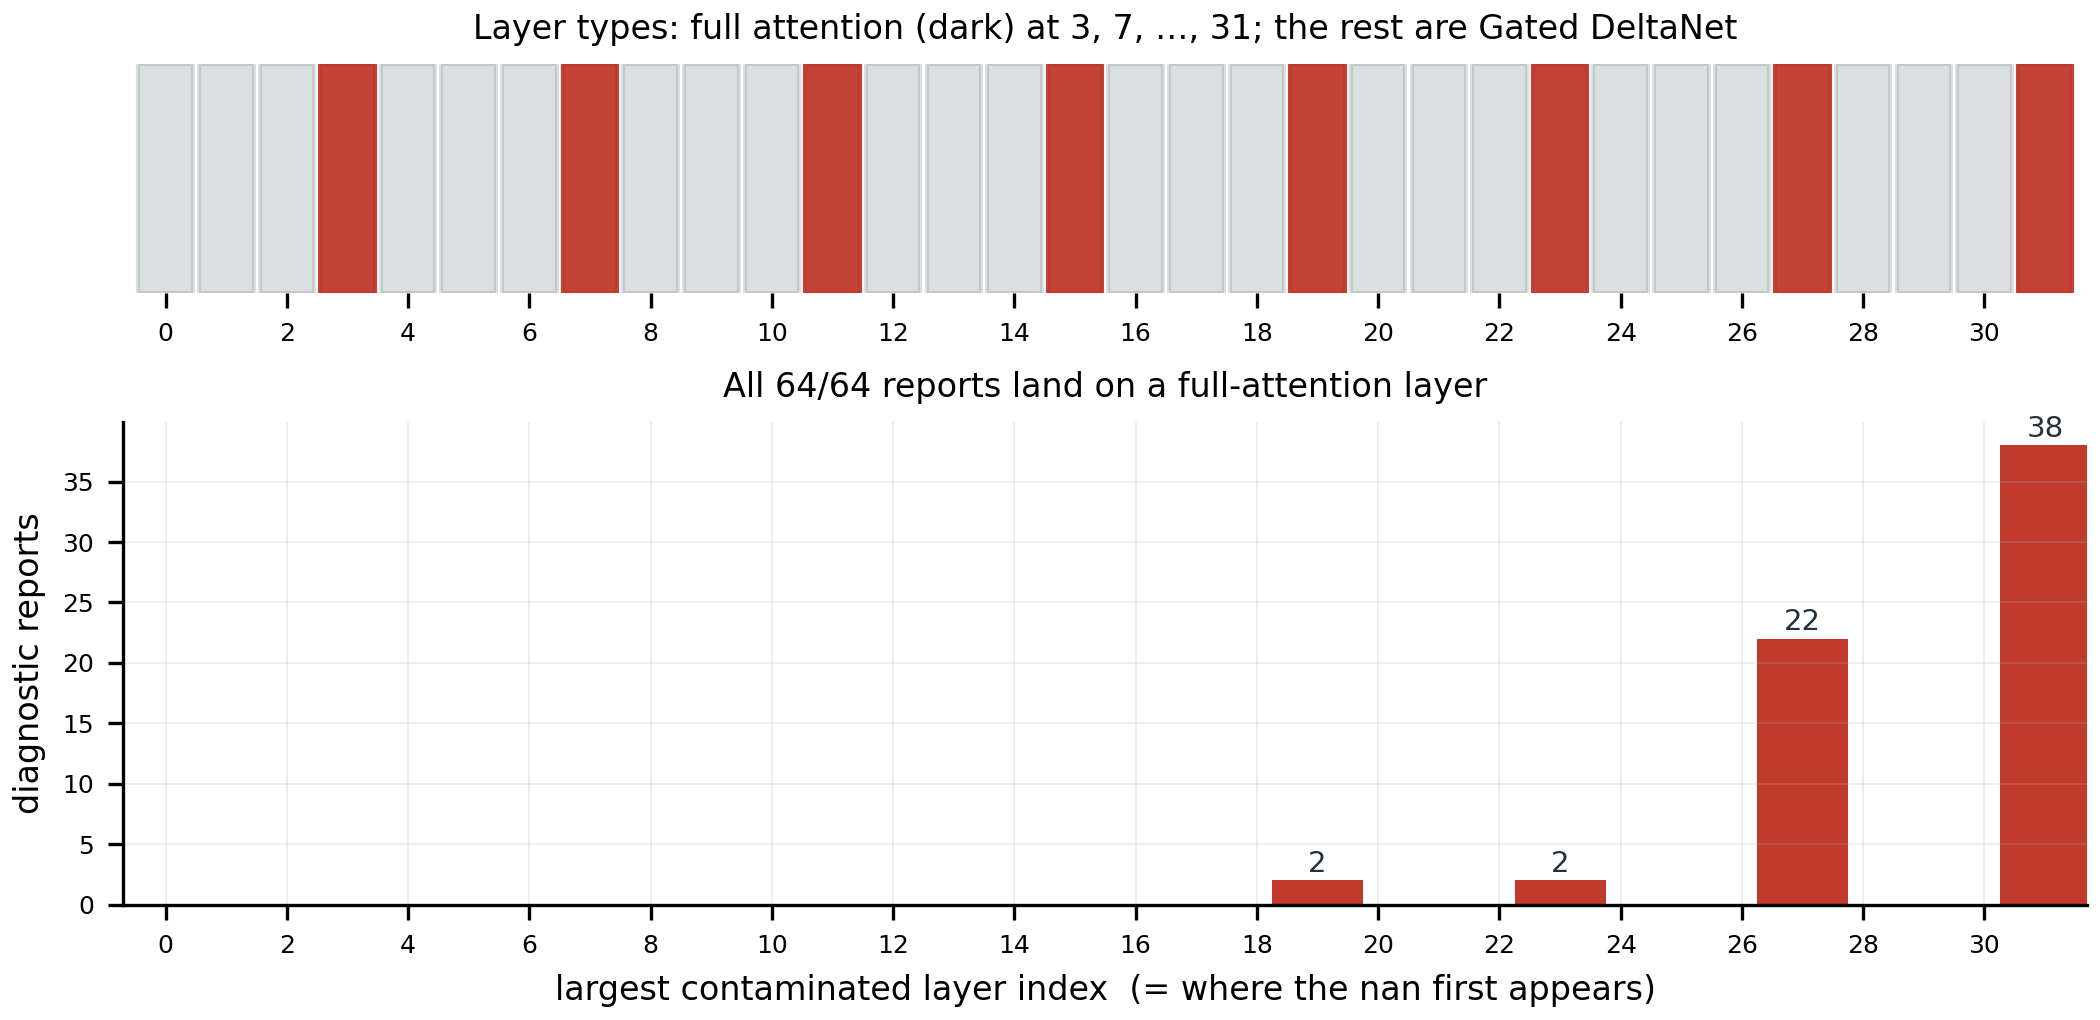

observed boundary layers: {19: 2, 23: 2, 27: 22, 31: 38}
full-attention layers   : [3, 7, 11, 15, 19, 23, 27, 31]
on a full-attention layer: 64/64
uniform-null p, counting only the 4 distinct values: 0.0039


In [6]:
spans = D["nan_spans"]; full = set(D["full_attention_layers"]); LT = D["layer_types"]
his = [s["hi"] for s in spans]
from collections import Counter
cnt = Counter(his)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.0, 3.4),
                             gridspec_kw={"height_ratios": [1, 2.1]})

for i, t in enumerate(LT):
    a1.add_patch(plt.Rectangle((i-0.45, 0), 0.9, 1,
                 color=(HL if i in full else MUTE), alpha=(0.95 if i in full else 0.35)))
a1.set_xlim(-0.7, len(LT)-0.3); a1.set_ylim(0, 1); a1.set_yticks([])
a1.set_xticks(range(0, len(LT), 2)); a1.tick_params(labelsize=6)
a1.grid(False); a1.set_frame_on(False)
a1.set_title("Layer types: full attention (dark) at 3, 7, …, 31; the rest are Gated DeltaNet",
             fontsize=8)

xs = sorted(cnt)
a2.bar(xs, [cnt[x] for x in xs], color=[HL if x in full else MUTE for x in xs], width=1.5)
for x in xs:
    a2.annotate(f"{cnt[x]}", (x, cnt[x]), textcoords="offset points", xytext=(0, 2),
                ha="center", fontsize=7, color=INK)
a2.set_xlim(-0.7, len(LT)-0.3)
a2.set_xticks(range(0, len(LT), 2)); a2.tick_params(labelsize=6)
a2.set_xlabel("largest contaminated layer index  (= where the nan first appears)")
a2.set_ylabel("diagnostic reports")
a2.set_title(f"All {len(his)}/{len(his)} reports land on a full-attention layer", fontsize=8)
show(fig)

print("observed boundary layers:", dict(sorted(cnt.items())))
print("full-attention layers   :", sorted(full))
print(f"on a full-attention layer: {sum(1 for h in his if h in full)}/{len(his)}")
print(f"uniform-null p, counting only the {len(cnt)} distinct values: {0.25**len(cnt):.4f}")

**The nan is created inside a full-attention layer's backward, not in the Gated DeltaNet.**
Under a uniform boundary the probability of landing in the 8-layer full-attention set is 1/4;
even counting only the four *distinct* observed values as independent, p = 0.004.

This overturns the campaign's own reasoning twice over. The earlier conclusion blamed the GDN
because `linear_attn.A_log` and `dt_bias` were nan in every report — but those are nan precisely
because they sit *downstream* in the backward, i.e. they are the most conspicuous members of the
set "everything already contaminated". A parameter that is always nan carries the least
information. The later conclusion then read `full_attention_interval: 4` as layers {0, 4, …, 28}
when the actual set is {3, 7, …, 31}, which misfiled the wavefront layer 28 — a GDN layer, and
the *last clean* one — as full attention. The right answer was reachable from the same logs by
counting instead of reading one line each.

## 6. What the design can and cannot resolve

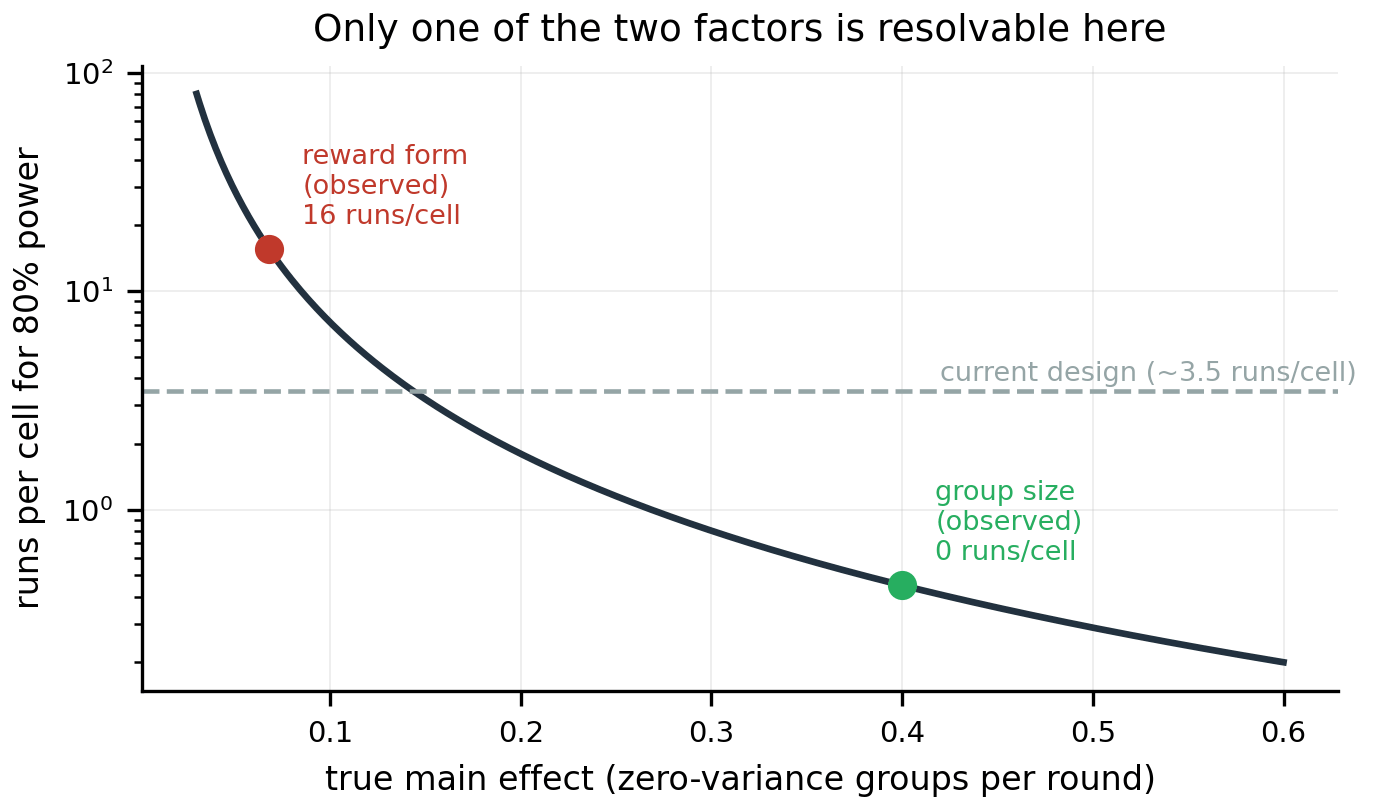

effect 0.068 (reward form ) ->   15.6 runs/cell
effect 0.100 (—           ) ->    7.2 runs/cell
effect 0.200 (—           ) ->    1.8 runs/cell
effect 0.400 (group size  ) ->    0.5 runs/cell


In [7]:
s = 0.0958                    # pooled within-cell SD of the run-level rate
z = 2.802                     # z(.975) + z(.80)
eff = np.linspace(0.03, 0.60, 400)
need = (z*s/eff)**2

fig, ax = plt.subplots(figsize=(4.6, 2.7))
ax.plot(eff, need, color=INK, lw=1.6)
ax.set_yscale("log")
ax.set_xlabel("true main effect (zero-variance groups per round)")
ax.set_ylabel("runs per cell for 80% power")

for x, lab, col in [(0.068, "reward form\n(observed)", HL),
                    (0.40,  "group size\n(observed)", OK)]:
    n = (z*s/x)**2
    ax.plot([x], [n], "o", color=col, ms=6)
    ax.annotate(f"{lab}\n{n:.0f} runs/cell", (x, n), textcoords="offset points",
                xytext=(8, 6), fontsize=6.5, color=col)
ax.axhline(3.5, color=MUTE, ls="--", lw=1.1)
ax.annotate("current design (~3.5 runs/cell)", (0.42, 3.9), fontsize=6.5, color=MUTE)
ax.set_title("Only one of the two factors is resolvable here")
show(fig)

for x, lab in [(0.068, "reward form"), (0.10, "—"), (0.20, "—"), (0.40, "group size")]:
    print(f"effect {x:.3f} ({lab:12}) -> {(z*s/x)**2:6.1f} runs/cell")

**The reward-form contrast needs about 16 runs per cell and the design has ~3.5.** Achieved power
against the observed effect is 21%. The group-size effect (+0.40, 95% CI [+0.28, +0.52],
permutation p = 0.0008) is large enough to be resolved and is stable at every truncation depth;
the reward-form effect (+0.07, CI spanning zero, p = 0.20) changes sign at shallow truncation and
is smaller than the run-to-run scatter *within* a single cell.

## 7. Where the GPU-hours went

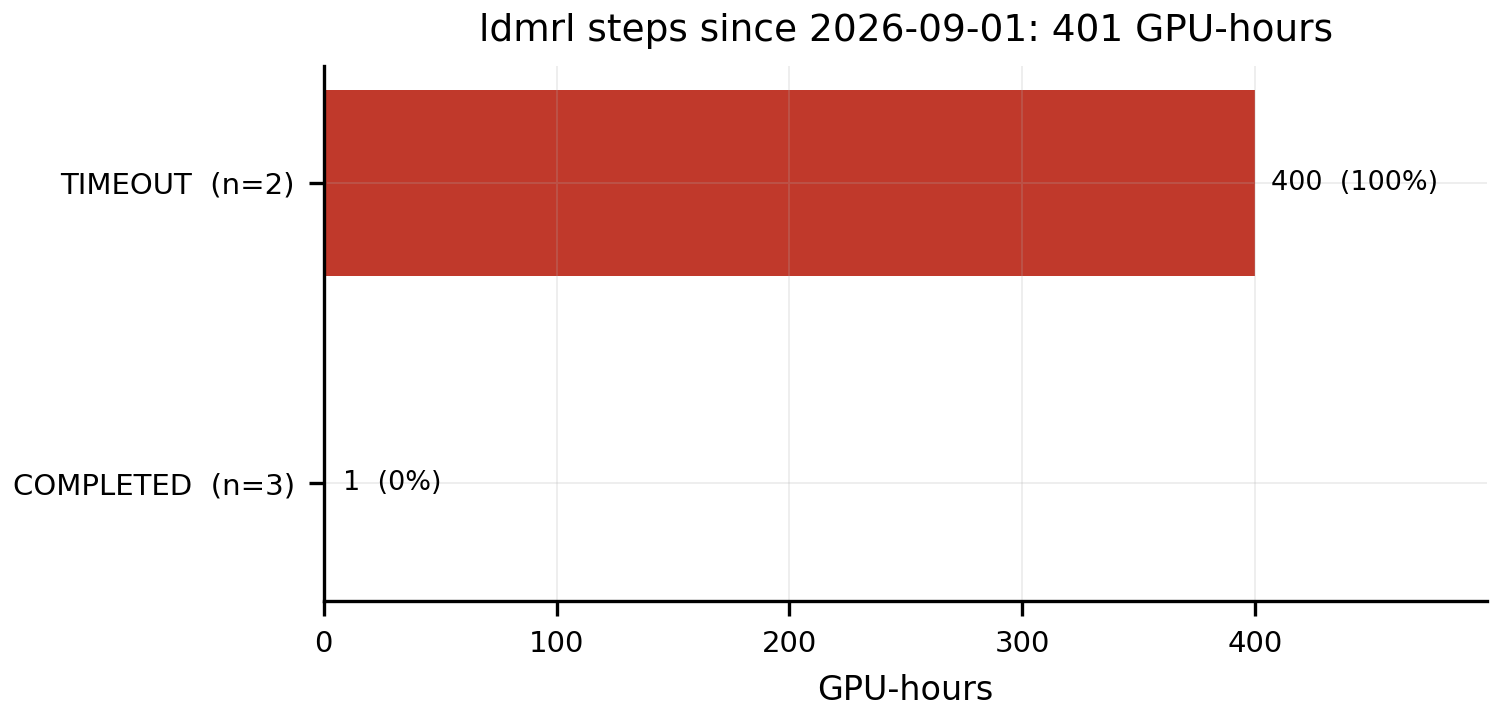

TIMEOUT           2 steps     399.9 GPU-h   99.8%
COMPLETED         3 steps       1.0 GPU-h    0.2%


In [8]:
w = D["gpu_waste"]
if w:
    order = sorted(w, key=lambda k: -w[k]["gpu_h"])
    vals = [w[k]["gpu_h"] for k in order]
    tot = sum(vals)
    cols = [OK if k == "COMPLETED" else (WARN if k == "RUNNING" else HL) for k in order]
    fig, ax = plt.subplots(figsize=(5.0, 2.4))
    b = ax.barh(range(len(order)), vals, color=cols, height=0.62)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([f"{k}  (n={w[k]['steps']})" for k in order], fontsize=7)
    ax.invert_yaxis(); ax.set_xlabel("GPU-hours")
    for i, v in enumerate(vals):
        ax.annotate(f"{v:.0f}  ({100*v/tot:.0f}%)", (v, i), textcoords="offset points",
                    xytext=(4, 0), va="center", fontsize=6.5)
    ax.set_xlim(0, max(vals)*1.25)
    ax.set_title(f"ldmrl steps since 2026-09-01: {tot:.0f} GPU-hours")
    show(fig)
    for k in order:
        print(f"{k:14} {w[k]['steps']:4} steps  {w[k]['gpu_h']:8.1f} GPU-h  {100*w[k]['gpu_h']/tot:5.1f}%")
else:
    print("no sacct data available in this environment")

A clean exit is an **upper** bound on productive time, not a measure of it: a run can complete
and still contribute nothing, and — as section 1 shows — several completed runs contributed a
number that turned out to mean nothing.

## 8. Claims audited

Every row was a written conclusion in the campaign record before this review.

In [9]:
import textwrap
rows = [
 ("raw_reward fell, so the policy got worse",
  "RETRACTED",
  "Reproduced at full size with the policy frozen; 50/64 runs decline; uncorrelated with how much the policy moved."),
 ("ΔHV and group size are independent factors (2.3x, 5.2x)",
  "NOT SUPPORTED",
  "Cells were compared at 60/22/52/133 rounds. At a common cut the two n=4 cells are equal."),
 ("acquisition + n=4 has zero-variance rate 0.000",
  "FALSE",
  "Truncation artefact: the events are late. The two long runs read 1/20 and 6/22."),
 ("Group size is an effective knob",
  "CONFOUNDED, effect survives",
  "n=4 also received 2x the optimiser steps. The rate effect is large and stable at every depth; the mechanism is not isolated."),
 ("9B applies 13.8% of optimiser steps",
  "NOT A RATE",
  "Per-run rates span 0 to 1.00; homogeneity rejected p=2e-8; denominator omits 42 runs that never reached the optimiser."),
 ("9B never had a healthy step",
  "SURVIVES",
  "38 finite gradients, all >= 2.5e7; the 1.5B range is 0.0099-1.7e5. Distributions disjoint."),
 ("advantage ~1e-8, so backward amplifies 1e15",
  "RETRACTED",
  "1e-8 is a float32 cancellation residue of a mean-zero quantity. With n=2 and std normalisation the advantage is exactly +/-0.7071."),
 ("nan starts at layer 28, which is full attention",
  "CORRECTED",
  "Layer 28 is Gated DeltaNet and is the last CLEAN layer. The boundary is 19/23/27/31 - full attention in 64/64 reports."),
 ("The nan is gradient explosion overflowing fp32",
  "NOT SUPPORTED",
  "Largest finite gradient 6.8e13 vs fp32 max 3.4e38 - 24 orders of headroom. It is a discrete 0*inf event."),
 ("Runs were killed by session teardown",
  "REFUTED",
  "The log redirect sat outside the remote shell, so train.log recorded the login-side client. Compute side ran on; sacct says COMPLETED."),
]
w1, w2 = 46, 22
print(f"{'claim':{w1}} {'verdict':{w2}} correction")
print("-"*(w1+w2+70))
for c, v, why in rows:
    cl = textwrap.wrap(c, w1) or [""]
    wl = textwrap.wrap(why, 68) or [""]
    n = max(len(cl), len(wl))
    for i in range(n):
        print(f"{cl[i] if i < len(cl) else '':{w1}} {v if i==0 else '':{w2}} {wl[i] if i < len(wl) else ''}")
    print()

claim                                          verdict                correction
------------------------------------------------------------------------------------------------------------------------------------------
raw_reward fell, so the policy got worse       RETRACTED              Reproduced at full size with the policy frozen; 50/64 runs decline;
                                                                      uncorrelated with how much the policy moved.

ΔHV and group size are independent factors     NOT SUPPORTED          Cells were compared at 60/22/52/133 rounds. At a common cut the two
(2.3x, 5.2x)                                                          n=4 cells are equal.

acquisition + n=4 has zero-variance rate 0.000 FALSE                  Truncation artefact: the events are late. The two long runs read
                                                                      1/20 and 6/22.

Group size is an effective knob                CONFOUNDED, effect survives 

## 9. Defects found and their status

In [10]:
fixes = [
 ("train.log redirect outside the remote shell", "FIXED",
  "exec > inside bash -lc; srun client logged separately. Ended a whole failure class."),
 ("global_batch hard-coded while n_samples was the knob", "FIXED",
  "UPDATES_PER_ROLLOUT declared, global_batch derived, divisibility asserted, triple printed."),
 ("gtop drops per-card lines in a narrow terminal", "FIXED",
  "COLUMNS=200; refill also refuses to read 0 card-lines as 'no free GPUs'."),
 ("refill required 4/4-free nodes", "FIXED",
  "The 1.5B launcher uses GPUs 1,2,3. Requiring 4/4 rejected 12 of 13 usable nodes."),
 ("architecture inferred from an unexpanded argv echo", "FIXED",
  "Discriminate on padded_vocab_size (248320 vs 151936), a resolved number."),
 ("per-layer gradient profile never emitted", "IN PROGRESS",
  "Block was added after the runs that were supposed to use it; also truncated to 14 of 32 layers."),
 ("advantage epsilon absolute while rewards span 1e-8..1e0", "IN PROGRESS",
  "Below std=1e-6 the eps dominates and GRPO silently loses scale invariance."),
 ("22,784-token micro-batch vs an 8,192 cap", "IN PROGRESS",
  "2.78x over the documented packing limit; it is what the 12.90 GiB fp32 logits OOM allocates for."),
 ("sglang 0.7 + actor 30.3 GB = 96.8 GB on a 95 GB card", "IN PROGRESS",
  "Over budget on paper; survives only when the two peaks miss each other."),
 ("MODEL_HF cross still live on the split path", "IN PROGRESS",
  "site_env.sh sets it unconditionally, so the launcher's ${MODEL_HF:-...} can never fire."),
 ("slime is a shared mutable checkout with uncommitted edits", "OPEN",
  "The worktree pin covers ldm_rl only; the diagnostic was rewritten in place with no version stamp."),
]
w1 = 50
print(f"{'defect':{w1}} {'status':13} note")
print("-"*(w1+13+72))
for d_, s_, n_ in fixes:
    dl = textwrap.wrap(d_, w1) or [""]
    nl = textwrap.wrap(n_, 70) or [""]
    for i in range(max(len(dl), len(nl))):
        print(f"{dl[i] if i < len(dl) else '':{w1}} {s_ if i==0 else '':13} {nl[i] if i < len(nl) else ''}")
    print()

defect                                             status        note
---------------------------------------------------------------------------------------------------------------------------------------
train.log redirect outside the remote shell        FIXED         exec > inside bash -lc; srun client logged separately. Ended a whole
                                                                 failure class.

global_batch hard-coded while n_samples was the    FIXED         UPDATES_PER_ROLLOUT declared, global_batch derived, divisibility
knob                                                             asserted, triple printed.

gtop drops per-card lines in a narrow terminal     FIXED         COLUMNS=200; refill also refuses to read 0 card-lines as 'no free
                                                                 GPUs'.

refill required 4/4-free nodes                     FIXED         The 1.5B launcher uses GPUs 1,2,3. Requiring 4/4 rejected 12 of 13
                     

## 10. What stands

1. **The 9B gradient pathology is real and total.** 38 finite gradients across 24 runs, every one
   at least 2.5e7; the 1.5B on the same code sits between 0.0099 and 1.7e5. The distributions
   do not overlap.

2. **The nan originates in a full-attention layer.** 64 of 64 diagnostic reports put the boundary
   on a layer in {3, 7, …, 31}. The Gated DeltaNet parameters that dominated the investigation
   for a week are downstream of it, and their being always-nan is what made them uninformative.

3. **It is not an overflow.** 24 orders of headroom separate the largest finite gradient from
   fp32's limit, so the mechanism is a discrete non-finite event, not smooth growth. This
   distinction decides the fix: scaling repairs overflow and does nothing for `0*inf`.

4. **Group size changes the zero-variance rate; reward form has not been shown to.** +0.40 groups
   per round [+0.28, +0.52] versus +0.07 with a CI spanning zero. But the group-size cells also
   received twice the optimiser steps, so the *mechanism* is not isolated — that is what the
   corrected launcher now makes measurable.

5. **No claim about policy improvement has ever been testable on this pipeline**, because the
   only outcome measure recorded falls on its own with the policy held fixed.

### Next measurements, in order of what they settle per GPU-hour

| # | Measurement | Settles | Cost |
|---|---|---|---|
| 1 | One 9B run with the repaired per-layer diagnostic printing `n_nan` vs `n_inf` untruncated | Whether the first non-finite value is `0*inf`, `inf-inf` or `0/0`, and in which operation | 1 node, ~20 min |
| 2 | The 2×2 refilled to 8 runs per cell with `UPDATES_PER_ROLLOUT` fixed | Group size as a mechanism rather than as a training-budget proxy | ~13 nodes, in flight |
| 3 | Frozen-GP yardstick replayed over completed runs | The first testable statement about policy quality | CPU only |
| 4 | Micro-batch token count instrumented at the packing site | Why a bin reaches 2.78× its cap | CPU + 1 run |

*Sections 1–7 are regenerated from `results/session_20260904.json`; re-running this notebook after
new runs land updates every number in place.*